# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> Data Science 2: Advanced Topics in Data Science

## Homework 1: Artificial Neural Networks and Regularization

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas & Kevin Rader

<hr style="height:2pt">


In [1]:
import random, os, sys, time, copy, gc
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tqdm.auto as tqdm_auto
from tqdm.autonotebook import tqdm as tqdm_notebook
from IPython.display import clear_output, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
from torch import randint

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    device = torch.device("cuda")
else:
    print("No GPU available. Training will run on CPU.")
    device = torch.device("cpu")

print(f"Using device: {device}")

# These optional libraries will be installed on Open OnDemand soon
# import torchvision
# from torchvision import transforms

SEED = 109
# Ensure deterministic behavior in PyTorch (Disable to avoid waiting until the heat death of the universe)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


GPU: NVIDIA GeForce RTX 4050 Laptop GPU is available.
Using device: cuda


In [2]:
def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)


In [14]:
# measure notebook runtime
time_start = time.time()


<div style = "background: lightsalmon; color: black; border: thin solid black; border-radius: 2px; padding: 5px">

### Instructions

- To submit your notebook, follow the instructions given in on the Canvas assignment page.
- Plots should be legible and interpretable _without having to refer to the code that generated them_. They should include axis labels as well as a descriptive title and/or legend when appropriate.
- When asked to interpret a visualization, do not simply describe it (e.g., "the curve has a steep slope up"), but instead explain what you believe the plot _means_.
- The use of _extremely_ inefficient or error-prone code (e.g., copy-pasting nearly identical commands rather than looping) may result in only partial credit.
- Leaving in blocks of commented-out or non-functional code may result in deductions. Your notebook should be neat and tidy for the human reader.
- We have tried to include all the libraries you may need to do the assignment in the imports cell provided below. Please get course staff approval before importing any additional 3rd party libraries.
- Enable scrolling output on cells with very long output. Or better still, limit such output when possible.
- Feel free to add additional code or markdown cells as needed.
- **You must do a "Restart Kernel and Run All Cells" before submitting to ensure (1) your notebook actually runs and (2) all output is visible.** This is another reason to be sure you are saving your models to disk and that your code will only train a model if the saved model is not found.
</div>


<!-- <div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA"> -->

## PART 1 [50 pts]: Model interpretation and predictive intervals in ANNs

### Overview and Data Description

In this problem, you will be building and interpreting models to predict whether a flight was delayed for its arrival. The model will be based on features that can be measured as the flight takes off.

We will also estimate the predictive intervals of the model using bootstrapping. We will utilize those predictive intervals to build a new kind of model: a model that refrains from making a prediction when it is not confident.

The variables in the original csv are:

**ARRIVAL_DELAY**: the difference between scheduled arrival and actual arrival, in minutes (positive is late, negative is early).

**DISTANCE**: the distance between arrival and departure airports, in miles.

**SCHEDULED_TIME**: the flight's scheduled travel time in minutes.

**MONTH**: the month the flight took off, 1 = January, 2 = February, etc.

**SCHED_DEP_HOUR**: the scheduled departure time (the hour of the day).

**SCHED_ARR_HOUR**: the scheduled arrival time (the hour of the day).

**FLIGHT_COUNT**: the number of flights flying out of the origin airport before noon on a typical day.

**DAY_OF_WEEK**: the day of the week, 1 = Monday, 2 = Tuesday, etc.

**ORIGIN_AIRPORT**: the airport the flight took off from.

**DESTINATION_AIRPORT**: the airport the flight was scheduled to land at.

For the airport codes, see: https://www.bts.gov/topics/airlines-and-airports/world-airport-codes

To successfully complete this part, you will proceed by fitting a NN model, evaluating its accuracy, interpreting the predictors' importance, and finally evaluating the predictive intervals.

**NOTE:** the observations were sampled so that roughly half of the observations were delayed and half of the observations were not delayed.

<!-- </div> -->


<div class='exercise-r'>

### 1.1 Flight Delay Dataset

**Note that this part (section 1.1) has been completed for you. Simply run the provided cells below to load and preprocess the data. While you do not need to write any code here, you are expected to read through the processing steps taken here so that you fully understand the data you'll be working with.**

</div>


<div class='exercise-r'>

#### 1.1.1 Loading the Data

Read in the dataset `data/flights.csv` into a DataFrame called `df_flights`. Create a new column in the DataFrame called `DELAY_OR_NOT`. This is a binary variable that denotes whether `ARRIVAL_DELAY` is greater-than-or-equal-to 15 minutes (the FAA and BTS define a flight as delayed by 15 minutes or more). This is going to be the response variable for the rest of part 1.

</div>


In [15]:
df_flights = pd.read_csv("data/flights.csv")
df_flights.info()
df_flights.head(5)


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ARRIVAL_DELAY        10000 non-null  int64  
 1   DISTANCE             9995 non-null   float64
 2   SCHEDULED_TIME       9999 non-null   float64
 3   MONTH                10000 non-null  int64  
 4   SCHED_DEP_HOUR       10000 non-null  int64  
 5   SCHED_ARR_HOUR       10000 non-null  int64  
 6   FLIGHT_COUNT         9995 non-null   float64
 7   DAY_OF_WEEK          10000 non-null  int64  
 8   ORIGIN_AIRPORT       10000 non-null  str    
 9   DESTINATION_AIRPORT  10000 non-null  str    
dtypes: float64(3), int64(5), str(2)
memory usage: 781.4 KB


,ARRIVAL_DELAY,DISTANCE,SCHEDULED_TIME,MONTH,SCHED_DEP_HOUR,SCHED_ARR_HOUR,FLIGHT_COUNT,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT
0,23,2586.0,342.0,9,7,15,240.0,3,SFO,JFK
1,10,1235.0,185.0,5,6,11,366.0,4,LAX,DFW
2,-7,184.0,76.0,4,17,18,172.0,7,BOS,LGA
3,68,862.0,148.0,7,19,21,260.0,7,IAH,DEN
4,24,236.0,71.0,3,20,21,266.0,2,LAS,LAX


In [16]:
df_flights["DELAY_OR_NOT"] = (df_flights["ARRIVAL_DELAY"] >= 15).astype(int)

delay_counts = df_flights["DELAY_OR_NOT"].value_counts().sort_index()

print(
    'The resulting counts for our "DELAY_OR_NOT" response variable,\n'
    "where class 1 are flights with actual arrivals 15 minutes late\n"
    "or later than scheduled, are:\n\n\tclass\tobservations"
)
for resp, value in zip(delay_counts.index, delay_counts.values):
    print("\t{}  \t{:,.0f}".format(resp, value))


The resulting counts for our "DELAY_OR_NOT" response variable,
where class 1 are flights with actual arrivals 15 minutes late
or later than scheduled, are:

	class	observations
	0  	5,069
	1  	4,931


<div class='exercise-r'>

#### 1.1.2 Preprocess the data

- Deal with missing values if there are any
- One-hot-encode the non-numeric categorical variables
- Split the data using an 80/20 train-test split with `random_state=111` and stratifying on the response variable
- Standardize train and test with the scaler fit on the train data

Print the resulting shapes of your $X$ and $y$ dataframes for both your train and your test sets.

**NOTE:** While inspecting your data, you may notice that a large number of airport codes are recorded using 5-digit values instead of the expected 3-letter codes. That is perfectly fine. Those 5-digit values should be considered valid and just be treated the same as they would be if they were 3-letter codes.

**TIPS:**

- month and day-of-the-week should be treated as numerical in this context.
- you should consider what predctors are acceptable to include given our goal is to predict if a flight is delayed.

</div>


In [17]:
# By displaying rows with missing values, we can see
# that ALL missing values occur for flights between
# BOS and SFO. This would indicate that these values are NOT
# missing at random. Therefore, we will want to impute our
# values rather than simply delete these rows
print("ALL MISSING VALUE ROWS, THEY APPEAR TO BE BOS TO SFO FLIGHTS:")
display(df_flights[df_flights.isnull().any(axis=1)])

# The next thing we will do is display all BOS to SFO observations
# to determine how we should treat missing values in each
# predictor column.
print("\nALL BOS TO SFO FLIGHT OBSERVATIONS (INCLD. THOSE WITH MISSINGNESS):")
loc_filter = (df_flights["ORIGIN_AIRPORT"] == "BOS") & (
    df_flights["DESTINATION_AIRPORT"] == "SFO"
)
display(df_flights.loc[loc_filter])

# We can see that we know the exact values to enter for missing
# DISTANCE and missing FLIGHT_COUNT values, so rather than
# impute, we can just explicilty set the values as such, being
# certain to fix the column dtypes as well
df_flights["DISTANCE"] = df_flights["DISTANCE"].fillna(2704).astype(int)
df_flights["FLIGHT_COUNT"] = df_flights["FLIGHT_COUNT"].fillna(172).astype(int)

# As for the one missing SCHEDULED_TIME value, we could do
# something more involved like creating some sort of imputation model
# (such as trying to predict that one value using kNN), but because it's only
# one value and there does not appear to be much variability in time among
# the flights between BOS and SFO, we can probably just get away with populating
# this cell with the mean SCHEDULED_TIME for all flights between BOS and SFO
mean_time = df_flights.loc[loc_filter]["SCHEDULED_TIME"].mean()
df_flights["SCHEDULED_TIME"] = (
    df_flights["SCHEDULED_TIME"].fillna(mean_time).astype(int)
)

# To wrap up, we'll print the df_flights info again to confirm no more
# missing values exist
print("\nTHE df_flights DATAFRAME AFTER RESOLVING MISSINGNESS:\n")
display(df_flights.info())


ALL MISSING VALUE ROWS, THEY APPEAR TO BE BOS TO SFO FLIGHTS:


,ARRIVAL_DELAY,DISTANCE,SCHEDULED_TIME,MONTH,SCHED_DEP_HOUR,SCHED_ARR_HOUR,FLIGHT_COUNT,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DELAY_OR_NOT
70,13,NaN,395.0,11,6,9,NaN,1,BOS,SFO,0
1566,-4,NaN,418.0,2,6,9,NaN,5,BOS,SFO,0
3741,-33,NaN,419.0,11,11,15,NaN,2,BOS,SFO,0
5612,-9,NaN,381.0,6,8,12,NaN,5,BOS,SFO,0
6375,17,NaN,NaN,7,18,21,NaN,3,BOS,SFO,1



ALL BOS TO SFO FLIGHT OBSERVATIONS (INCLD. THOSE WITH MISSINGNESS):


,ARRIVAL_DELAY,DISTANCE,SCHEDULED_TIME,MONTH,SCHED_DEP_HOUR,SCHED_ARR_HOUR,FLIGHT_COUNT,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DELAY_OR_NOT
70,13,NaN,395.0,11,6,9,NaN,1,BOS,SFO,0
155,-17,2704.0,390.0,8,7,10,172.0,6,BOS,SFO,0
1566,-4,NaN,418.0,2,6,9,NaN,5,BOS,SFO,0
1729,16,2704.0,390.0,9,20,23,172.0,1,BOS,SFO,1
2775,-9,2704.0,403.0,3,11,14,172.0,1,BOS,SFO,0
3132,101,2704.0,412.0,2,16,20,172.0,4,BOS,SFO,1
3741,-33,NaN,419.0,11,11,15,NaN,2,BOS,SFO,0
5612,-9,NaN,381.0,6,8,12,NaN,5,BOS,SFO,0
5929,-5,2704.0,404.0,3,6,9,172.0,1,BOS,SFO,0
6375,17,NaN,NaN,7,18,21,NaN,3,BOS,SFO,1



THE df_flights DATAFRAME AFTER RESOLVING MISSINGNESS:

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ARRIVAL_DELAY        10000 non-null  int64
 1   DISTANCE             10000 non-null  int64
 2   SCHEDULED_TIME       10000 non-null  int64
 3   MONTH                10000 non-null  int64
 4   SCHED_DEP_HOUR       10000 non-null  int64
 5   SCHED_ARR_HOUR       10000 non-null  int64
 6   FLIGHT_COUNT         10000 non-null  int64
 7   DAY_OF_WEEK          10000 non-null  int64
 8   ORIGIN_AIRPORT       10000 non-null  str  
 9   DESTINATION_AIRPORT  10000 non-null  str  
 10  DELAY_OR_NOT         10000 non-null  int64
dtypes: int64(9), str(2)
memory usage: 859.5 KB


None

In [18]:
# identify our response variable
response = "DELAY_OR_NOT"

# identify categorical predictors for one-hot-encoding
cat_preds = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

# identify columns we will need to drop from X after encoding
drop_cols = ["ARRIVAL_DELAY", response] + cat_preds

# one-hot-encode and make certain to drop one col for each predictor
df_one_hot = pd.get_dummies(df_flights[cat_preds], drop_first=True)

# merge encoded columns with other predictor columns to create
# our X data, being certain to drop non-predictor columns
X_flights = pd.concat(
    [
        df_flights.drop(columns=drop_cols),
        df_one_hot,
    ],
    axis=1,
)
y_flights = df_flights[response]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_flights, y_flights, test_size=0.20, random_state=111, stratify=y_flights
)

# scale X data and retain our original X dataframes
X_train_val_std = X_train_val.copy()
X_test_std = X_test.copy()

scaler = StandardScaler().fit(X_train_val)
X_train_val_std[X_train_val.columns] = scaler.transform(X_train_val)
X_test_std[X_test.columns] = scaler.transform(X_test)

X_train_only, X_val, y_train_only, y_val = train_test_split(
    X_train_val_std,
    y_train_val,
    test_size=0.25,
    random_state=SEED,
    stratify=y_train_val,
)


# print our resulting X and y shapes
print(
    "The shapes of our resulting X and y train and test sets are:\n\n"
    "\tX_train_val\t{}\n\ty_train_val\t{}\n\n"
    "\tX_train\t\t{}\n\ty_train\t\t{}\n\n\tX_val\t\t{}\n\ty_val\t\t{}\n\n"
    "\tX_test\t\t{}\n\ty_test\t\t{}\n".format(
        X_train_val.shape,
        y_train_val.shape,
        X_train_only.shape,
        y_train_only.shape,
        X_val.shape,
        y_val.shape,
        X_test.shape,
        y_test.shape,
    )
)


The shapes of our resulting X and y train and test sets are:

	X_train_val	(8000, 808)
	y_train_val	(8000,)

	X_train		(6000, 808)
	y_train		(6000,)

	X_val		(2000, 808)
	y_val		(2000,)

	X_test		(2000, 808)
	y_test		(2000,)



<div class='exercise-r'>

### 1.2 Fit an ANN

Fit an artificial neural network model using all predictors (name this model `NN_model`). Use a dense feed-forward network with two hidden layers with 15 nodes in each hidden layer. For this network, use a reasonable activation functions for the hidden layers and output, select an appropriate loss function and optimizer, specify a validation split of 0.2, and train for a reasonable number of epochs and batch size of your choice. Plot the training accuracy and validation accuracy as a function of epochs from your `NN_model`'s training history. Evaluate the `NN_model` model on both train and test, and print out the resulting train and test accuracies.

You should base your choice of "a reasonable number of epochs" on a visualization of the model's training history.

<a id="q12"></a>

</div>


In [19]:
# build your NN
class Connected_ReLU_Binary_Classifier_NN_Factory:
    def __init__(self, input_dim, output_dim, shape):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.shape = copy.deepcopy(shape)

    def build(self):
        set_seed()
        ordered_dict = self._build_ordered_dict()
        return nn.Sequential(ordered_dict)

    def _build_ordered_dict(self):
        shape_builder = copy.deepcopy(self.shape)
        layer_number = 1
        ordered_dict = OrderedDict()
        prev_dim = self.input_dim
        while shape_builder:
            nneurons, nlayers = shape_builder.pop(0)
            if nneurons == 0 or nlayers == 0:
                raise ValueError(
                    "Invalid shape specification: number of neurons and layers "
                    "in each section must be greater than 0."
                )
            ordered_dict[f"affine{layer_number}"] = nn.Linear(prev_dim, nneurons)
            ordered_dict[f"relu{layer_number}"] = nn.ReLU()
            layer_number += 1
            nlayers -= 1
            while nlayers > 0:
                ordered_dict[f"affine{layer_number}"] = nn.Linear(nneurons, nneurons)
                ordered_dict[f"relu{layer_number}"] = nn.ReLU()
                layer_number += 1
                nlayers -= 1
            prev_dim = nneurons
        ordered_dict[f"affine{layer_number}"] = nn.Linear(prev_dim, self.output_dim)
        ordered_dict[f"sigmoid{layer_number}"] = nn.Sigmoid()
        return ordered_dict


FlightDelayNN_Factory = Connected_ReLU_Binary_Classifier_NN_Factory(
    input_dim=X_train_only.shape[1], output_dim=1, shape=[(15, 2)]
)


In [ ]:
def flight_delay_nn(X_train, y_train, progressbar=False):
    set_seed()

    # config
    model = FlightDelayNN_Factory.build()
    model.train()
    # train the model on X_train_std and y_train, using binary cross-entropy loss and the Adam optimizer
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.05)
    num_epochs = 15
    batch_size = 32
    # create DataLoader for training data
    train_dataset = TensorDataset(
        torch.tensor(X_train.values, dtype=torch.float32),
        torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1),
    )
    train_batches = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # output data
    epoch_to_state_dict = []

    # it's training time!
    iterable = (
        tqdm_auto.tqdm(range(num_epochs), desc="Training Epochs", leave=False)
        if progressbar
        else range(num_epochs)
    )
    for _ in iterable:
        # per mini-batch
        loss = None
        for inputs, labels in train_batches:
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        # record epoch data
        epoch_to_state_dict.append(copy.deepcopy(model.state_dict()))

    return epoch_to_state_dict


In [84]:
epoch_to_state_dict = flight_delay_nn(X_train_only, y_train_only)


Training Epochs: 100%|██████████| 15/15 [00:02<00:00,  5.22it/s]


In [ ]:
def evaluate_epoch_to_acc(epoch_to_state_dict, X_train, y_train):
    epoch_to_train_acc = []
    epoch_to_val_acc = []
    epoch_to_test_acc = []
    epoch_to_test_y_pred_proba = []
    with torch.no_grad():
        for state_dict in epoch_to_state_dict:
            model = FlightDelayNN_Factory.build()
            model.load_state_dict(state_dict)
            model.eval()

            train_y_pred_proba = (
                model(torch.tensor(X_train.values, dtype=torch.float32)).cpu().numpy()
            )
            train_y_pred = (train_y_pred_proba >= 0.5).astype(int)
            train_acc = accuracy_score(y_train, train_y_pred)
            epoch_to_train_acc.append(train_acc)

            val_y_pred_proba = (
                model(torch.tensor(X_val.values, dtype=torch.float32)).cpu().numpy()
            )
            val_y_pred = (val_y_pred_proba >= 0.5).astype(int)
            val_acc = accuracy_score(y_val, val_y_pred)
            epoch_to_val_acc.append(val_acc)

            test_y_pred_proba = (
                model(torch.tensor(X_test_std.values, dtype=torch.float32))
                .cpu()
                .numpy()
            )
            test_y_pred = (test_y_pred_proba >= 0.5).astype(int)
            test_acc = accuracy_score(y_test, test_y_pred)
            epoch_to_test_acc.append(test_acc)
            epoch_to_test_y_pred_proba.append(test_y_pred_proba)

    return {
        "train_acc": epoch_to_train_acc,
        "val_acc": epoch_to_val_acc,
        "test_acc": epoch_to_test_acc,
        "test_y_pred_proba": epoch_to_test_y_pred_proba,
    }


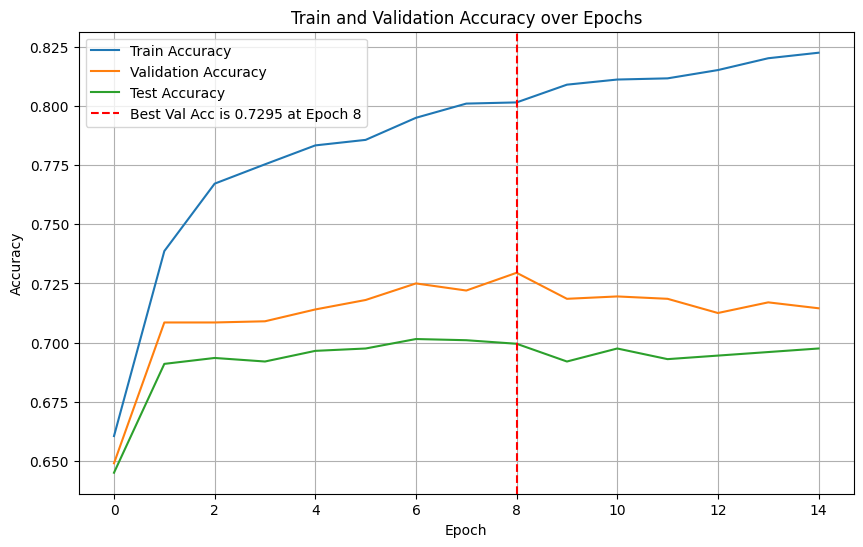

In [ ]:
# plot train and val acc as a function of epochs
results = evaluate_epoch_to_acc(epoch_to_state_dict, X_train_only, y_train_only)
best_val_acc_epoch = np.argmax(results["val_acc"])

plt.figure(figsize=(10, 6))
plt.plot(results["train_acc"], label="Train Accuracy")
plt.plot(results["val_acc"], label="Validation Accuracy")
plt.plot(results["test_acc"], label="Test Accuracy")
plt.axvline(
    x=best_val_acc_epoch,
    color="red",
    linestyle="--",
    label=f"Best Val Acc is {results['val_acc'][best_val_acc_epoch]:.4f} at Epoch {best_val_acc_epoch}",
)
plt.title("Train and Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [88]:
# evaluate on train and test and print accuracy results
print(f"Epoch {best_val_acc_epoch}:\n")
print(f"\tTrain Accuracy: {results['train_acc'][best_val_acc_epoch]:.4f}")
print(f"\tTest Accuracy: {results['test_acc'][best_val_acc_epoch]:.4f}")


Epoch 8:

	Train Accuracy: 0.8015
	Test Accuracy: 0.6995


<div class='exercise-r'>

### 1.3 Bootstrap prediction intervals

In CS1090A, we saw how we could use MCMC to perform Bayesian inference on the parameters of linear and logistic regression models. This gave us access not only to samples from the posterior distribution (betas) but we could also generate samples from the posterior predictive distribution (data). The posterior predictive can be used to represent our uncertainty about a given prediction, $\hat{y}$.

We'd like to do something similar for our neural network here so that we can quantify the uncertainty in our predictions. But there are some problems. First, we haven't (explicitly) specified any priors on the network weights. Second, and more serious, neural networks have many, many parameters. Far too many for MCMC to be a viable approach. Sampling in such a high dimensional space is simply intractable.

Bootstrap to the rescue!

Using the same network architecture as `NN_model` (layers, nodes, activations, etc.) and the scaled data you used with that model, create multiple training sets through bootstrapping, fitting a separate neural network model to each bootstrapped set of data (the number of bootstraped _datasets_, $n$, should be at least 50). For each of the $n$ models, make predictions on the test data. Randomly select 8 test observations and on 8 subplots, plot the distribution of the $n$ predicted probabilities with the 95% prediction intervals clearly marked and reported in each subplot and the **actual** class of each observation included in each subplot's title for easy reference.

Interpret what you see in 3-5 sentences.

**NOTE:** The code for this problem can take an extremely long time to execute. Please feel free to use the `progressbar` function provided below to visually track the progress of your bootstraps.

<a id="q13"></a>

</div>


In [ ]:
def progressbar(n_step, n_total):
    """Prints self-updating progress bar to stdout to track for-loop progress

    There are entire 3rd-party libraries dedicated to custom progress-bars.
    A simple function like this is often more than enough to get the job done.

    :param n_total: total number of expected for-loop iterations
    :type n_total: int
    :param n_step: current iteration number, starting at 0
    :type n_step: int

    .. example::

        for i in range(n_iterations):
            progressbar(i, n_iterations)

    .. source:

        This function is a simplified version of code found here:
        https://stackoverflow.com/questions/3160699/python-progress-bar/15860757#15860757
    """
    n_step = n_step + 1
    barlen = 50
    progress = n_step / n_total
    block = int(round(barlen * progress))
    status = ""
    if n_step == n_total:
        status = "Done...\r\n\n"
    text = "\r [{0}] {1}/{2} {3}".format(
        "=" * block + "-" * (barlen - block),
        n_step,
        n_total,
        status,
    )
    sys.stdout.write(text)
    sys.stdout.flush()


In [ ]:
%%time
# Bootstrap and train your networks and get predictions on X test
n_bootstraps = 100
bootstrap_test_y_pred_proba = []
for i in tqdm_auto.tqdm(range(n_bootstraps), desc="Bootstraps", leave=True):
    # create bootstrap sample
    X_train_bootstrap, y_train_bootstrap = resample(
        X_train_only, y_train_only, replace=True, random_state=SEED + i
    )
    # train model on bootstrap sample and get epoch_to_state_dict
    epoch_to_state_dict = flight_delay_nn(X_train_bootstrap, y_train_bootstrap)
    # evaluate epoch_to_state_dict on test set and get test_y_pred_proba for each epoch
    results = evaluate_epoch_to_acc(epoch_to_state_dict, X_val, y_val)
    best_val_acc_epoch = np.argmax(results["val_acc"])
    bootstrap_test_y_pred_proba.append(
        results["test_y_pred_proba"][best_val_acc_epoch].squeeze()
    )
bootstrap_test_y_pred_proba = np.array(bootstrap_test_y_pred_proba)


Bootstraps: 100%|██████████| 100/100 [05:35<00:00,  3.35s/it]

CPU times: user 59min 48s, sys: 13.9 s, total: 1h 2s
Wall time: 5min 35s


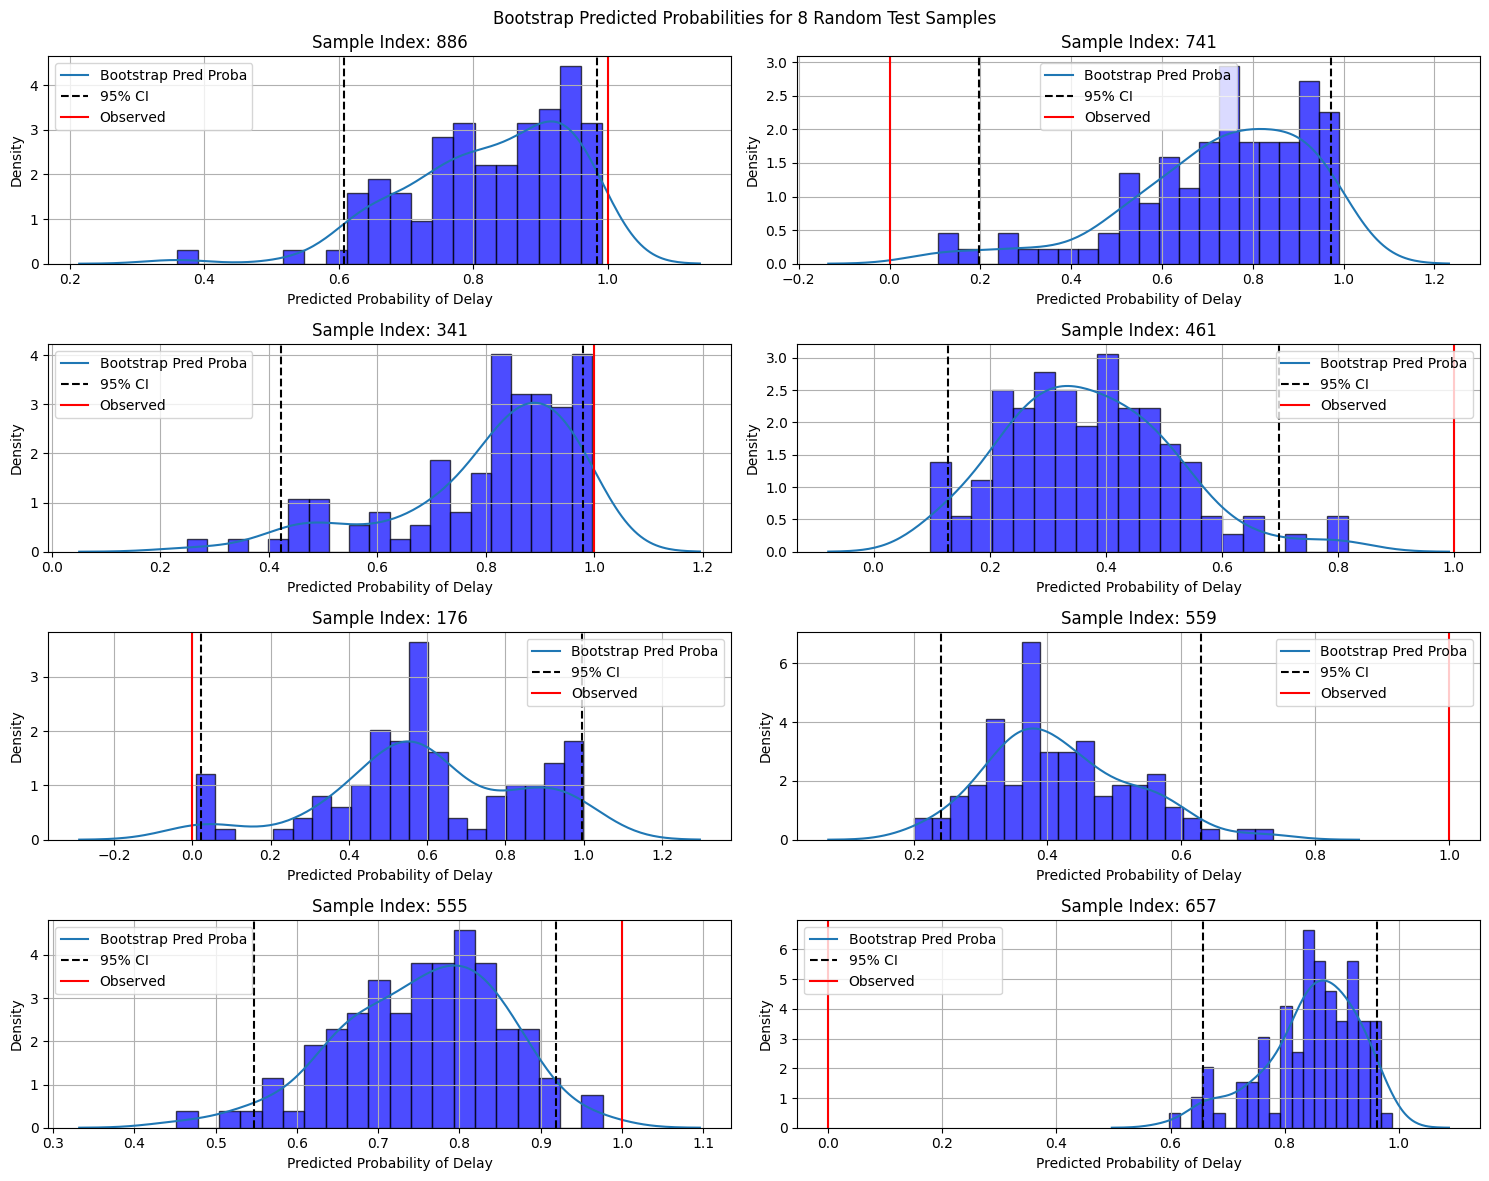

In [ ]:
# generate your plot
set_seed()
eight_sample_idxs = randint(0, len(X_test_std), (8,)).tolist()
eight_sample_data = [
    {
        "idx": idx,
        "y_true": y_test.iloc[idx],
        "y_pred_proba": bootstrap_test_y_pred_proba[:, idx],
        "ci_lower": np.percentile(bootstrap_test_y_pred_proba[:, idx], 2.5),
        "ci_upper": np.percentile(bootstrap_test_y_pred_proba[:, idx], 97.5),
    }
    for idx in eight_sample_idxs
]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 12))
plt.suptitle("Bootstrap Predicted Probabilities for 8 Random Test Samples")
for ax1, sample in zip(axes.flatten(), eight_sample_data):
    ax1.hist(
        sample["y_pred_proba"],
        density=True,
        bins=20,
        alpha=0.7,
        color="blue",
        edgecolor="black",
    )
    sns.kdeplot(
        sample["y_pred_proba"], ax=ax1, color="blue", label="Bootstrap Pred Proba"
    )
    ax1.axvline(
        x=sample["ci_lower"],
        color="black",
        linestyle="--",
        label="95% CI",
    )
    ax1.axvline(
        x=sample["ci_upper"],
        color="black",
        linestyle="--",
    )
    ax1.axvline(
        x=sample["y_true"],
        color="red",
        label="Observed",
    )
    ax1.set_title(f"Sample Index: {sample['idx']}")
    ax1.set_xlabel("Predicted Probability of Delay")
    ax1.set_ylabel("Density")
    ax1.legend()
    ax1.grid()
plt.tight_layout()
plt.show()


There's a diverse amount of interpretations for each predicted point. Some points have a tight prediction distribution, while others are more wide. This corresponds to how sure the model is about the predicted proba. However, this confidence means different things at different places. The points that have a tight distribution around 0.9 are very confidently predicted to be delayed, for example, but a tight distribution around 0.5 means the model is confidently confused! Also, when the distribution is wide, it means the model is unsure, which is a distinct state from the tight distribution around 0.5.

In addition, the point could be confidently wrong or unconfidently correct, which add another layer of interpretation as to how well the model is doing.


<div class='exercise-r'>

### 1.4 Build an "abstain" bagging model

Using the probability distribution of the predictions obtained from the bootstrapped samples above, we can evaluate how confident we should be in our bagged (i.e. bootstrap-aggregated) predictions for each test observation.

To accomplish this, you will first calculate a metric we'll call the **Posterior Prediction Dissent (PPD)** related to the proportion of predictions a given test observation receives for the minority opinion. Some examples: if 10% of the bootstrapped models predict $\hat{y} = 0$ with the remaining 90% predicting $\hat{y}=1$, then the $PPD=0.1$. When a bagged prediction's $PPD=0$, all predictions are compatible (i.e. all bootstrapped probabilities for that test observation are on the same side of $\hat{p}=0.5$). Likewise, when the $PPD=0.5$, half of the bootstrapped predictions for that test observation are $\hat{y}=0$, and the other half are $\hat{y}=1$. After calculating your $PPD$ values for all test observations, you should have $n=2000$ $PPD$ values (i.e. one for each test observation).

Next, to get more accurate predictions, we can create an **abstain** model that will abstain from making a prediction for a particular observation if some defined threshold for lack-of-confidence (i.e. maximum permissible $PPD$ value) is crossed. (If you'd like to learn more about abstain models, you can read more [here](https://openreview.net/forum?id=rJxF73R9tX).)

Let's explore how your resulting test accuracies might change by using your bootstrapped prediction results from question 1.3 for an **abstain bagging model** (i.e. a bootstrap aggregated model where some test observations are simply not predicted based on a given $PPD$ threshold). You can make your abstain model _stricter_ by using smaller $PPD$ threshold values.

- Print the test accuracy for your **bagging model** predictions from question 1.3 using predictions for all 2,000 of our test observations.

- Plot the test accuracies for an **abstain bagging model** using your predictions from question 1.3 as a function of increasing $PPD$.

- Also, plot the proportion of test observations not abstained (i.e. the proportion of those predicted) for your **abstain bagging model** as a function of increasing $PPD$.

- Interpret what you see in 3-5 sentences.

**NOTE**: You should observe that as $PPD$ decreases (more confident predictions), you must also compromise on the number of points that your abstain model is permitted to predict on.

**HINT:**

- What is the range of values PPD can take on? Is it the same as the range of our predictions themselves?
- When calculating accuracies, you should only consider those observations that received predictions (i.e., not the abstained observations)
</div>


In [92]:
bagging_test_y_pred_proba = np.mean(bootstrap_test_y_pred_proba, axis=0)
bagging_test_y_pred = (bagging_test_y_pred_proba >= 0.5).astype(int)
bagging_test_acc = accuracy_score(y_test, bagging_test_y_pred)
print(f"Bagging Test Accuracy: {bagging_test_acc:.4f}")


Bagging Test Accuracy: 0.7030


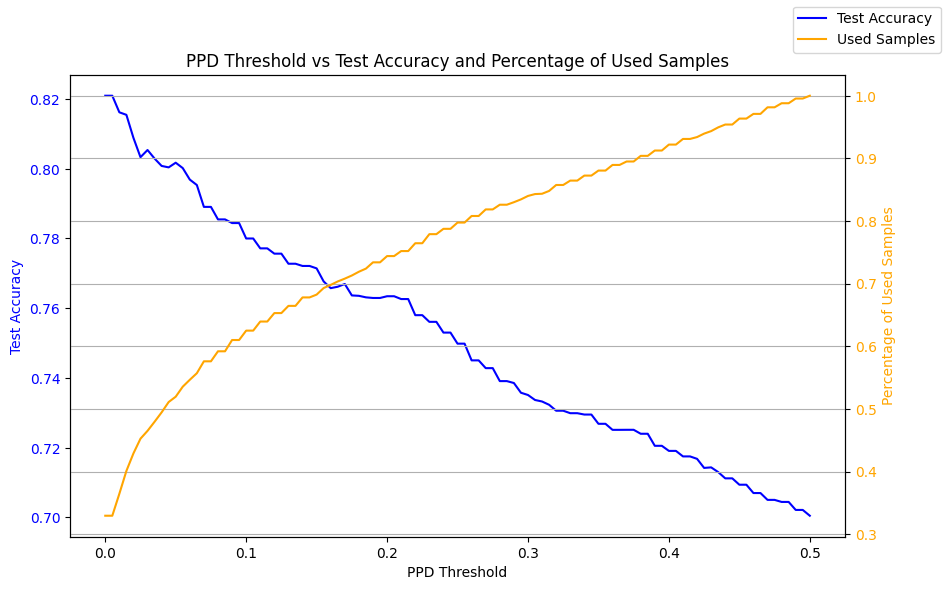

In [93]:
voting_percentages = np.mean((bootstrap_test_y_pred_proba >= 0.5).astype(int), axis=0)
voting_y_pred = (voting_percentages >= 0.5).astype(int)

ppd_thresholds = np.linspace(0, 0.5, 101)
ppd_threshold_to_test_acc = []
ppd_threshold_to_percentage_used = []
for threshold in ppd_thresholds:
    thresholded_voting_y_pred = []
    thresholded_voting_y_true = []
    for entry in range(len(voting_percentages)):
        if voting_y_pred[entry] == 0 and voting_percentages[entry] <= threshold:
            thresholded_voting_y_pred.append(0)
            thresholded_voting_y_true.append(y_test.iloc[entry])
        elif voting_y_pred[entry] == 1 and 1 - voting_percentages[entry] <= threshold:
            thresholded_voting_y_pred.append(1)
            thresholded_voting_y_true.append(y_test.iloc[entry])
    acc = accuracy_score(thresholded_voting_y_true, thresholded_voting_y_pred)
    ppd_threshold_to_test_acc.append(acc)
    ppd_threshold_to_percentage_used.append(
        len(thresholded_voting_y_true) / len(voting_percentages)
    )

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(111)
ax1.plot(ppd_thresholds, ppd_threshold_to_test_acc, color="blue", label="Test Accuracy")
ax1.set_xlabel("PPD Threshold")
ax1.set_ylabel("Test Accuracy", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax2 = ax1.twinx()
ax2.plot(
    ppd_thresholds,
    ppd_threshold_to_percentage_used,
    color="orange",
    label="Used Samples",
)
ax2.set_ylabel("Percentage of Used Samples", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
plt.title("PPD Threshold vs Test Accuracy and Percentage of Used Samples")
fig.legend(loc="upper right")
plt.grid()
plt.show()


As expected, the test accuracy increases as we decrease the PPD threshold, since it implies we only take the more confident results. In any good model, this should be the case, or else it means our model is more confident when wrong. It's also interesting to not that the accuracy curve is not necessarily monotone, which represents the inherent noise when making predictions.

Another interesting thing about the PPD-accuracy curve is how it captures one measure of model health. Similar to the ROC-AUC curve, which determines performance across all possible classification thresholds, the PPD-accuracy curve determines performance across all possible confidence thresholds (0.0 to 0.5). This AUC measure could almost be akin to a "is this model and/or data fundamentally flawed or variant?" measure, since a lower PPD-accuracy means that even when confident, predictions are hard to get right. In that case, e.g. with college admissions, it may be a sign that even the data or data engineering isn't great and we need more or better data to get good predictions.


<!-- <div class="alert alert-block alert-danger" style="color:black;background-color:#E7F4FA"> -->

## PART 2 [50 pts]: The Quick, Draw! Kaggle competition

### Problem Statement

Artificial neural networks (ANNs) are prone to overfitting, learning patterns specific to the training data that do not generalize to new data.

There are several methods to reduce ANN generalization error.

One approach is to use an architecture just barely wide or deep enough to fit the data. The idea here is that smaller networks are less expressive and thus less likely to overfit the data.

However, it is difficult to know a priori the correct size of the ANN, and it is computationally costly to hunt for the correct size. Given this, other methodologies are used to prevent overfitting and improve ANNs' generalizability. These methodologies, like other techniques that combat overfitting, fall under the umbrella term of "regularization."

### The Quick, Draw! Dataset

![](./img/quickdrawpreview.jpg)

For this problem, we will be working with a modified version of the [The Quick, Draw! Dataset](https://github.com/googlecreativelab/quickdraw-dataset), which is a large database of 50 million drawings across 345 categories, collected from players of the game [Quick, Draw!](https://quickdraw.withgoogle.com/).

For this homework, we will simplify the problem by using only 120,000 images across 10 different classes for training (this includes the data you will use for validation) and a test set of 30,000 images.

### Downloading the Data Files

**The required `train.csv` and `test.csv` data files are available on [the "Data" tab of the CS1090B HW1 Kaggle Competition website](https://www.kaggle.com/t/9b2ecc1d068c4cc592e4d3f4116b38dc). They are also included with this assignment in `data/quickdraw.zip`. (DO NOT USE DATA FROM ANY OTHER SOURCE!)**

Here's a brief description of the data files:

- `train.csv` is our training dataset and the `label` column contains our response class. The 784 other columns correspond to the pixel values of the 28x28 dimension image. `train.csv` has 120,000 samples.

- `test.csv` file mirrors the structure of the `train.csv` file **without** the class label column. We have added another column `id`. `id` is a unique identifier for each sample in the test set. This ID is crucial for mapping your model's predictions back to the corresponding samples when submitting your results to Kaggle. `test.csv` has 30,000 samples.

- Since the `test.csv` does not include the true labels, it is used exclusively for generating predictions that you'll submit to Kaggle for evaluation. Your task is to predict the class labels for each sample in `test.csv` and submit these predictions in the required format.

Kaggle leaderboard scores are accuracy scores calculated by Kaggle when you upload your predictions on this test set.

- `sample_submission.csv` is the format that kaggle will accept. The uploaded `.csv` must contain 2 columns. The first column must be named `id` and needs to contain the test observation index numbers for each prediction, the second must be named `label` and needs to contain your class predictions (i.e. 'cat', 'dog' etc) for each corresponding test observation index location.

### CS1090B Kaggle Competition

**ACCESS AND JOIN THE COMPETITION**:

**You need to create an account on Kaggle and [join the competition via this link](https://www.kaggle.com/t/9b2ecc1d068c4cc592e4d3f4116b38dc). This is a limited participation competition. Please DO NOT share this link.**

**For more information on the rules** governing this CS1090B Kaggle competition, please see below and also review the modeling restrictions DOS and DON'TS outlined below.

**IMPORTANT NOTES ABOUT SCORING**:

- The **public leaderboard** on Kaggle displays your performance on only 30% of the test set.

- After the competition is complete, the **private leaderboard** will show your performance on the remaining 70% of the test set.

- Question 2.3.7 is worth 30 points (the entire notebook is scored out of 100). Points for this questions will be awarded based on the **private leaderboard** accuracy score using the scoring function defined in [this notebook](https://colab.research.google.com/drive/1BqvxSDXwm4wfns1gfVGsEiV_fx_wZjOG?usp=sharing).

**ADDITIONAL COMPETITION RULES:**

- Multiple Kaggle submissions are permitted (with a maximum of 5 submissions per team per-day), **just note that you will need to choose, on Kaggle, the ONE single submission to use for final scoring prior to the final HW1 submission deadline**, and **your submitted notebook MUST contain the matching code and model that generated your ONE chosen submission.**

- **To repeat this point, the version of your final HW1 notebook submitted on Canvas MUST contain the same code and exact same model used to generate your ONE chosen Kaggle submission.** (TFs may rerun your notebook code to ensure comparable final leaderboard results.)

- **Please do not manually label your submissions.** In other words, the labels should only be the outcome of your model.

- **No external data are allowed**, you MUST USE ONLY the training and test data downloaded via the "Data" tab of the CS1090B competition page linked above.

- **Do not** create multiple accounts on Kaggle.


<div class='exercise-r'>

### 2.1 Download and visualize the data

- The data was included with the HW1 zip but can also be downloaded from [the competition page](https://www.kaggle.com/t/9b2ecc1d068c4cc592e4d3f4116b38dc).
- You will utilize `test.csv` in question 2.3.6.
- Load the training data and use the matplotlib function `imshow` to display 25 samples from each of the 10 classes from the training set. Total of 250 samples, 10 rows of 25 images each.
- You are responsible for any preprocessing you deem necessary to help in your prediction task.

</div>


In [3]:
# das a big boi
qd_train_df = pd.read_csv("./data/quickdraw/train.csv")
qd_train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Columns: 785 entries, 0 to label
dtypes: int64(784), str(1)
memory usage: 718.7 MB


In [4]:
qd_test_df = pd.read_csv("./data/quickdraw/test.csv")
qd_test_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Columns: 785 entries, 0 to id
dtypes: int64(785)
memory usage: 179.7 MB


In [5]:
qd_train_df["label"] = qd_train_df["label"].astype("category")
qd_labels = qd_train_df["label"].cat.categories
qd_labels


Index(['apple', 'butterfly', 'car', 'cat', 'dog', 'duck', 'face', 'skull',
       'swan', 'tree'],
      dtype='str')

In [6]:
# confirming we only have 0 or 255 (useful for MinMaxScaler() later)
np.unique(
    np.concatenate(
        (
            qd_train_df.drop(columns=["label"]).values,
            qd_test_df.drop(columns=["id"]).values,
        )
    )
)


array([  0, 255])

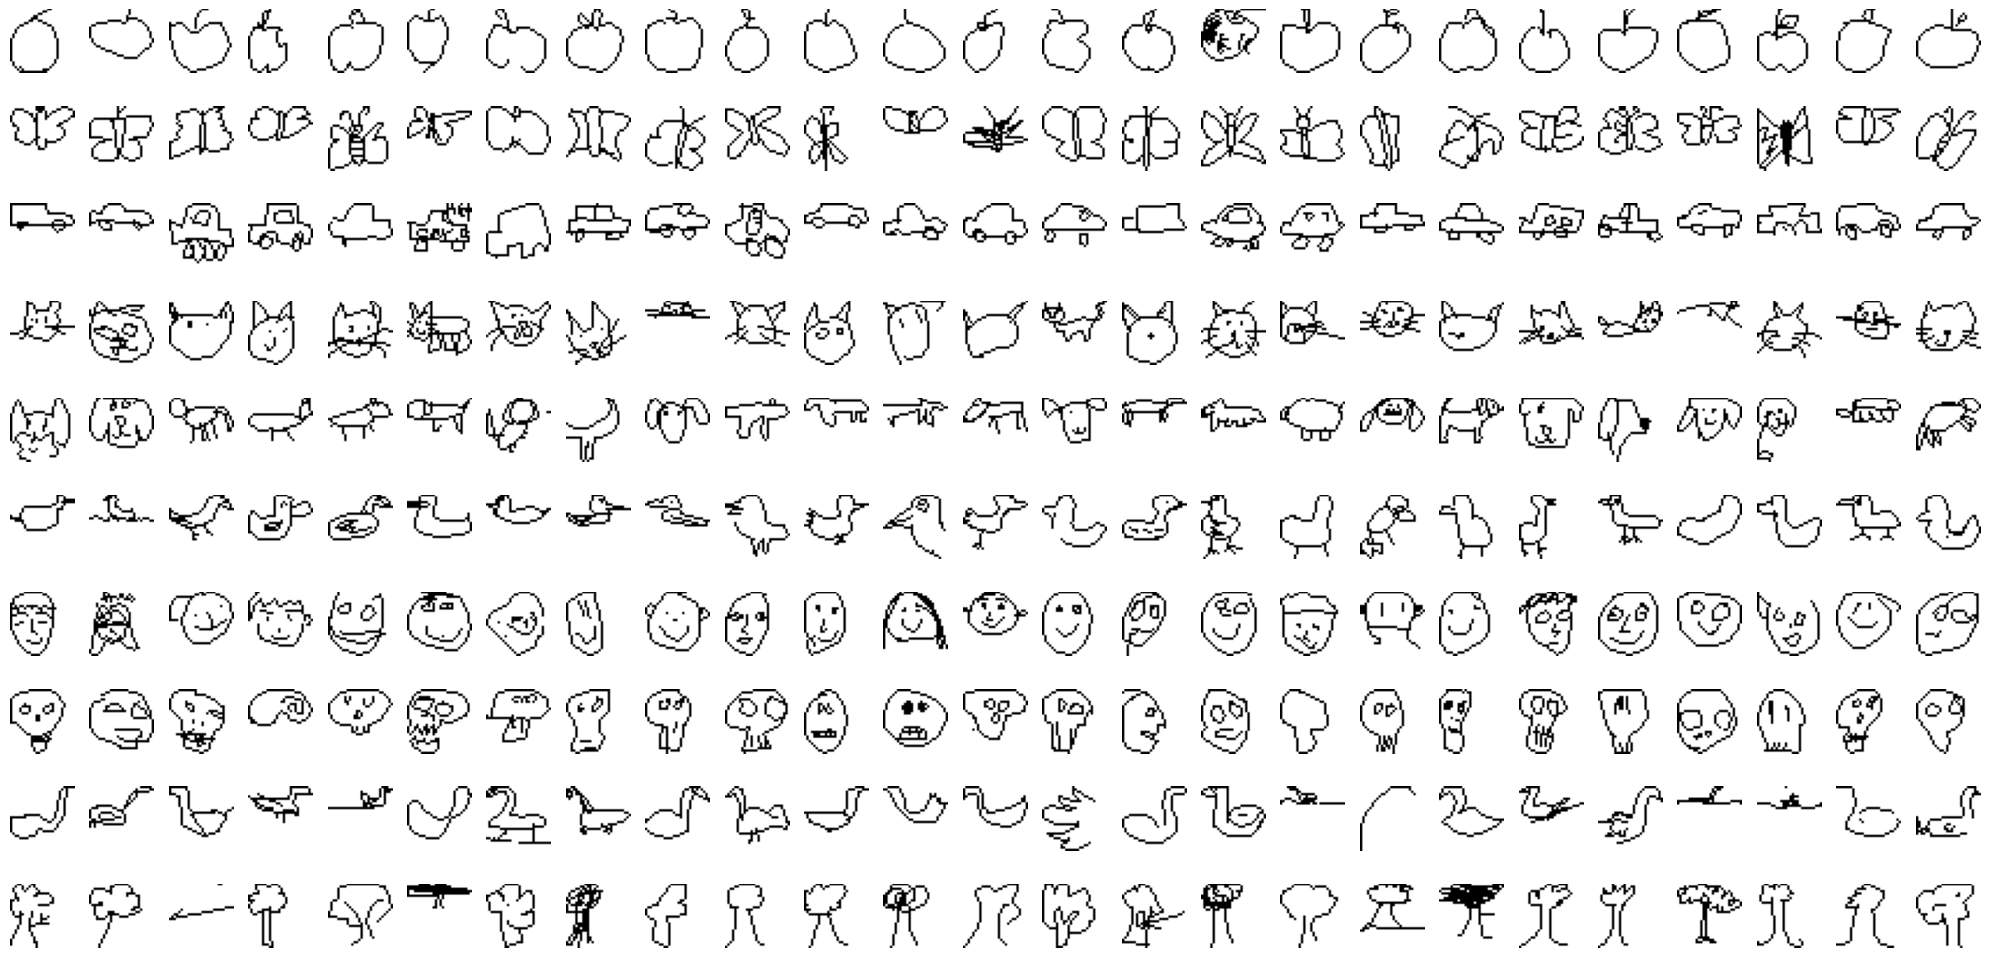

In [7]:
qd_samples = {}
for label in qd_labels:
    samples = qd_train_df[qd_train_df["label"] == label].sample(n=25, random_state=SEED)
    qd_samples[label] = samples.drop(columns=["label"]).values.reshape(-1, 28, 28)

fig, axes = plt.subplots(nrows=10, ncols=25, figsize=(20, 10))
it = enumerate(axes.flatten())
for label in qd_labels:
    for sample in qd_samples[label]:
        i, ax1 = next(it)
        ax1.imshow(sample, cmap="grey")
        ax1.axis("off")
plt.tight_layout()
plt.show()


hmm... some of these... are debatable categorizations...


<div class='exercise-r'>

### 2.2 Overfit an ANN

Build and fit a fully-connected network (FCN) with the architecture given below using `torch` and assign it to a variable called `model_overfit`:

- **Model type:** fully-connected network (FCN / MLP) for **10-class** classification
- **Hidden layers:** 3 fully-connected hidden layers
- **Hidden units:** 10,000 -> 10,000 -> 10,000
- **Hidden activation:** ReLU
- **Output layer:** a fully-connected layer with **10 outputs** producing **logits** (unnormalized class scores)
- **Training loss:** **multiclass cross-entropy** (negative log-likelihood of the correct class under a softmax over logits).
- **Optimizer:** Adam with default settings (no tuning)
- **Epochs:** 20
- **Batch size:** 128
- **Validation split:** 0.2 (hold out 20% of the training set as validation)

This ANN, when trained on the dataset, will overfit to the training set. Plot the training accuracy and validation accuracy (the x-axis should represent the number of epochs, and the y-axis should represent the accuracy). Explain how you can tell the model is overfitting.

</div>


In [6]:
# build your NN
class FCN_ReLU_Multiclassifier_NN_Factory:
    def __init__(self, input_dim, output_dim, shape, dropout=0.0, batch_norm=False):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.shape = copy.deepcopy(shape)
        self.dropout = dropout
        self.batch_norm = batch_norm

    def build(self):
        set_seed()
        ordered_dict = self._build_ordered_dict()
        return nn.Sequential(ordered_dict)

    def _add_hidden_block(self, ordered_dict, layer_number, in_dim, out_dim):
        """Add a single hidden block: Linear → [BatchNorm] → ReLU → [Dropout]."""
        ordered_dict[f"affine{layer_number}"] = nn.Linear(in_dim, out_dim)
        if self.batch_norm:
            ordered_dict[f"batchnorm{layer_number}"] = nn.BatchNorm1d(out_dim)
        ordered_dict[f"relu{layer_number}"] = nn.ReLU()
        if self.dropout > 0:
            ordered_dict[f"dropout{layer_number}"] = nn.Dropout(self.dropout)

    def _build_ordered_dict(self):
        shape_builder = copy.deepcopy(self.shape)
        layer_number = 1
        ordered_dict = OrderedDict()
        prev_dim = self.input_dim
        while shape_builder:
            nneurons, nlayers = shape_builder.pop(0)
            if nneurons == 0 or nlayers == 0:
                raise ValueError(
                    "Invalid shape specification: number of neurons and layers "
                    "in each section must be greater than 0."
                )
            self._add_hidden_block(ordered_dict, layer_number, prev_dim, nneurons)
            layer_number += 1
            nlayers -= 1

            while nlayers > 0:
                self._add_hidden_block(ordered_dict, layer_number, nneurons, nneurons)
                layer_number += 1
                nlayers -= 1
            prev_dim = nneurons
        # Output layer: raw logits for use with CrossEntropyLoss, which applies softmax internally
        ordered_dict[f"affine{layer_number}"] = nn.Linear(prev_dim, self.output_dim)
        return ordered_dict


In [8]:
# splits
overfit_label_encoder = LabelEncoder().fit(qd_train_df["label"])
overfit_scaler = MinMaxScaler().fit(qd_train_df.drop(columns=["label"]))

overfit_X_train_val = overfit_scaler.transform(qd_train_df.drop(columns=["label"]))
overfit_y_train_val = overfit_label_encoder.transform(qd_train_df["label"])

overfit_X_train, overfit_X_val, overfit_y_train, overfit_y_val = train_test_split(
    overfit_X_train_val,
    overfit_y_train_val,
    test_size=0.2,
    random_state=SEED,
    stratify=overfit_y_train_val,
    shuffle=True,
)

overfit_X_test = overfit_scaler.transform(qd_test_df.drop(columns=["id"]))


In [ ]:
OverfitNN_Factory = FCN_ReLU_Multiclassifier_NN_Factory(
    input_dim=overfit_X_train.shape[1], output_dim=len(qd_labels), shape=[(10_000, 3)]
)


In [ ]:
OVERFIT_CHECKPOINT_DIR = Path("./models/checkpoints/overfit")
OVERFIT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def overfit_nn_train(X_train, y_train, progressbar=1, resume_from=None):
    # clear gpu cache
    gc.collect()
    torch.cuda.empty_cache()

    set_seed()

    # config
    model = OverfitNN_Factory.build().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())
    num_epochs = 20
    batch_size = 128
    start_epoch = 0

    # resume from checkpoint if provided
    if resume_from is not None:
        checkpoint = torch.load(resume_from, weights_only=True)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resuming from epoch {start_epoch}")

    model.train()

    # create DataLoader for training data
    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32).to(device),
        torch.tensor(y_train, dtype=torch.long).to(device),
    )
    train_batches = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # it's training time!
    epoch_range = range(start_epoch, num_epochs)
    epoch_it = (
        tqdm_notebook(epoch_range, desc="Training Epochs", leave=True)
        if progressbar > 0
        else epoch_range
    )
    for epoch in epoch_it:
        # per mini-batch
        loss = None
        batch_it = (
            tqdm_notebook(train_batches, desc="Batches", leave=False)
            if progressbar > 1
            else train_batches
        )
        for inputs, labels in batch_it:
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # save checkpoint to disk
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": loss.item(),
            },
            OVERFIT_CHECKPOINT_DIR / f"epoch_{epoch}.pt",
        )

    # Free GPU memory after training completes
    del model, optimizer, train_dataset, train_batches, criterion
    gc.collect()
    torch.cuda.empty_cache()


In [ ]:
OVERFIT_METRICS_DIR = Path("./models/metrics/overfit")
OVERFIT_METRICS_DIR.mkdir(parents=True, exist_ok=True)


def overfit_evaluate_epoch_to_acc(
    checkpoint_dir=OVERFIT_CHECKPOINT_DIR,
    metrics_dir=OVERFIT_METRICS_DIR,
    progressbar=True,
    batch_size=1024,
):
    # Free leftover GPU memory from training
    gc.collect()
    torch.cuda.empty_cache()

    epoch_to_train_acc = []
    epoch_to_train_loss = []
    epoch_to_val_acc = []
    epoch_to_val_loss = []
    epoch_files = sorted(
        checkpoint_dir.glob("epoch_*.pt"), key=lambda p: int(p.stem.split("_")[1])
    )

    X_train_t = torch.tensor(overfit_X_train, dtype=torch.float32)
    X_val_t = torch.tensor(overfit_X_val, dtype=torch.float32)
    y_val_t = torch.tensor(overfit_y_val, dtype=torch.long)

    model = OverfitNN_Factory.build().to(device)

    def predict_in_batches(
        model,
        X,
        batch_size,
        progressbar=True,
        progressbar_name="",
    ):
        all_preds = []
        all_logits = []
        batches_it = (
            tqdm_notebook(
                range(0, len(X), batch_size),
                desc=f"Predicting Batches: {progressbar_name}",
                leave=False,
            )
            if progressbar
            else range(0, len(X), batch_size)
        )
        for i in batches_it:
            batch = X[i : min(i + batch_size, len(X))].to(device)
            logits = model(batch).cpu()
            all_preds.append(torch.argmax(logits, dim=1))
            all_logits.append(logits)
            del batch
        return torch.cat(all_preds).numpy(), torch.cat(all_logits)

    epoch_files_it = (
        tqdm_notebook(epoch_files, desc="Evaluating Epochs", leave=True)
        if progressbar
        else epoch_files
    )
    with torch.no_grad():
        for ckpt_path in epoch_files_it:
            checkpoint = torch.load(ckpt_path, weights_only=True, map_location="cpu")
            model.load_state_dict(checkpoint["model_state_dict"])
            model.eval()

            train_y_pred, train_logits = predict_in_batches(
                model,
                X_train_t,
                batch_size,
                progressbar=progressbar,
                progressbar_name="Train",
            )
            train_acc = accuracy_score(overfit_y_train, train_y_pred)
            train_loss = F.cross_entropy(
                train_logits, torch.tensor(overfit_y_train)
            ).item()
            epoch_to_train_acc.append(train_acc)
            epoch_to_train_loss.append(train_loss)

            val_y_pred, val_logits = predict_in_batches(
                model,
                X_val_t,
                batch_size,
                progressbar=progressbar,
                progressbar_name="Validation",
            )
            val_acc = accuracy_score(overfit_y_val, val_y_pred)
            val_loss = F.cross_entropy(val_logits, y_val_t).item()
            epoch_to_val_acc.append(val_acc)
            epoch_to_val_loss.append(val_loss)
            del val_logits

    # Clean up GPU after evaluation
    del model
    gc.collect()
    torch.cuda.empty_cache()

    # save metrics to disk
    metrics_df = pd.DataFrame(
        {
            "epoch": list(range(len(epoch_to_train_acc))),
            "train_acc": epoch_to_train_acc,
            "train_loss": epoch_to_train_loss,
            "val_acc": epoch_to_val_acc,
            "val_loss": epoch_to_val_loss,
        }
    )
    metrics_df.to_csv(metrics_dir / "epoch_metrics.csv", index=False)


In [ ]:
# Train (or resume with: resume_from=OVERFIT_CHECKPOINT_DIR / "epoch_X.pt")
overfit_nn_train(
    overfit_X_train,
    overfit_y_train,
    progressbar=2,
    resume_from=OVERFIT_CHECKPOINT_DIR / "epoch_19.pt",
)


Resuming from epoch 11


Training Epochs:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

Batches:   0%|          | 0/750 [00:00<?, ?it/s]

In [26]:
overfit_evaluate_epoch_to_acc()


Evaluating Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Predicting Batches: Train:   0%|          | 0/94 [00:00<?, ?it/s]

Predicting Batches: Validation:   0%|          | 0/24 [00:00<?, ?it/s]

Predicting Batches: Train:   0%|          | 0/94 [00:00<?, ?it/s]

Predicting Batches: Validation:   0%|          | 0/24 [00:00<?, ?it/s]

...

Predicting Batches: Validation:   0%|          | 0/24 [00:00<?, ?it/s]

Predicting Batches: Train:   0%|          | 0/94 [00:00<?, ?it/s]

Predicting Batches: Validation:   0%|          | 0/24 [00:00<?, ?it/s]

Predicting Batches: Train:   0%|          | 0/94 [00:00<?, ?it/s]

Predicting Batches: Validation:   0%|          | 0/24 [00:00<?, ?it/s]

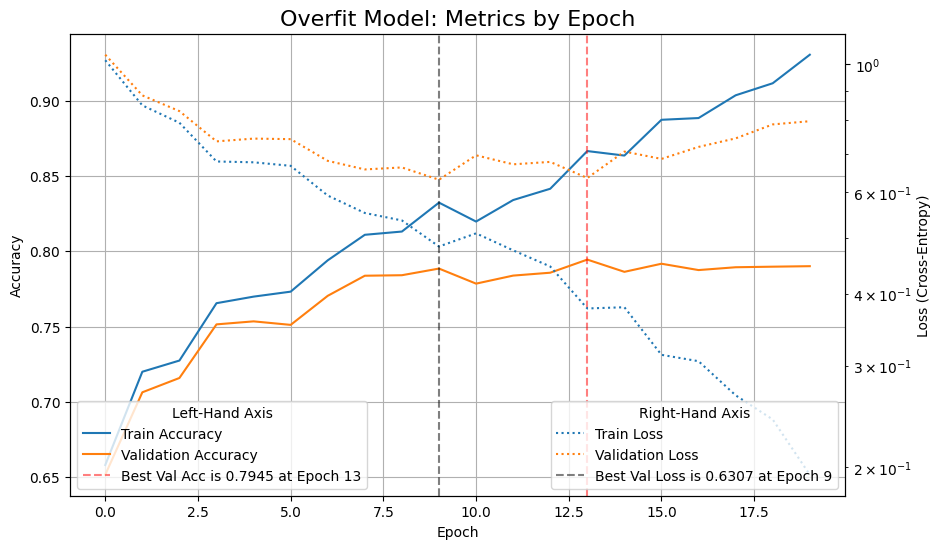

Final Train Accuracy: 0.9305
Final Validation Accuracy: 0.7902


In [32]:
# plot train and val acc as a function of epochs for the overfit model
overfit_results = pd.read_csv(OVERFIT_METRICS_DIR / "epoch_metrics.csv")

overfit_best_val_acc_epoch = overfit_results["val_acc"].idxmax()
overfit_best_val_loss_epoch = overfit_results["val_loss"].idxmin()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(
    overfit_results["epoch"],
    overfit_results["train_acc"],
    label="Train Accuracy",
)
ax1.plot(
    overfit_results["epoch"],
    overfit_results["val_acc"],
    label="Validation Accuracy",
)
ax1.axvline(
    x=overfit_best_val_acc_epoch,
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Best Val Acc is {overfit_results.loc[overfit_best_val_acc_epoch, 'val_acc']:.4f} "
    + f"at Epoch {overfit_best_val_acc_epoch}",
)
ax1.set_title("Overfit Model: Metrics by Epoch", fontsize=16)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend(loc="lower left", title="Left-Hand Axis")
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(
    overfit_results["epoch"],
    overfit_results["train_loss"],
    label="Train Loss",
    linestyle=":",
)
ax2.plot(
    overfit_results["epoch"],
    overfit_results["val_loss"],
    label="Validation Loss",
    linestyle=":",
)
ax2.axvline(
    x=overfit_best_val_loss_epoch,
    color="black",
    linestyle="--",
    alpha=0.5,
    label=f"Best Val Loss is {overfit_results.loc[overfit_best_val_loss_epoch, 'val_loss']:.4f} "
    + f"at Epoch {overfit_best_val_loss_epoch}",
)
ax2.set_ylabel("Loss (Cross-Entropy)")
ax2.set_yscale("log")
ax2.legend(loc="lower right", title="Right-Hand Axis")

plt.show()

print(f"Final Train Accuracy: {overfit_results.tail(1)['train_acc'].values[0]:.4f}")
print(f"Final Validation Accuracy: {overfit_results.tail(1)['val_acc'].values[0]:.4f}")


In [ ]:
# generate test predictions for the overfit model using the best val acc epoch checkpoint
SUBMISSION_DIR = Path("./models/submissions/overfit")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

gc.collect()
torch.cuda.empty_cache()

best_ckpt_path = OVERFIT_CHECKPOINT_DIR / f"epoch_{overfit_best_val_acc_epoch}.pt"
checkpoint = torch.load(best_ckpt_path, weights_only=True, map_location="cpu")
model = OverfitNN_Factory.build().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
X_test_t = torch.tensor(overfit_X_test, dtype=torch.float32).to(device)
test_logits = []
batch_size = 1024
with torch.no_grad():
    for i in tqdm_notebook(
        range(0, len(X_test_t), batch_size),
        desc="Predicting Test Batches",
        leave=True,
    ):
        batch = X_test_t[i : min(i + batch_size, len(X_test_t))].to(device)
        logits = model(batch).cpu()
        test_logits.append(logits)
        del batch
test_logits = torch.cat(test_logits)
test_y_pred = torch.argmax(test_logits, dim=1).numpy()

gc.collect()
torch.cuda.empty_cache()

test_y_pred_labels = qd_label_encoder.inverse_transform(test_y_pred)
submission_df = pd.DataFrame(
    {
        "id": qd_test_df["id"],
        "label": test_y_pred_labels,
    }
)
submission_df.to_csv(SUBMISSION_DIR / "quickdraw_submission.csv", index=False)


Predicting Test Batches:   0%|          | 0/30 [00:00<?, ?it/s]

The biggest giveaway that the model is overfitting is the name of the subproblem (i.e. Overfit an ANN).

Jokes aside, the model quickly learns the training data very well, but the same is not true of the validation data. We can see this in the distances between the blue and orange lines in the graph above. By the time the model reaches maximum validation accuracy, there's a massive 7-8% discrepancy between the train and val accuracies. In addition, the loss is worse, with the val Cross Entropy at 1.5x the train Cross Entropy at the chosen (by val acc) epoch.

The overfitting is especially apparent from the validation loss's plateuing at epoch 6 or 7, compared to the train loss's continual and speedy improvement even at epoch 20.


### 2.3 Improving the Network


#### 2.3.1 Enhancing Feature Extraction with Fourier Transforms

**[209 requirement; optional for others]**

Neural networks can learn useful representations of their inputs while simultaneously solving tasks like classification. This process, called **representation learning**, can be seen as a form of feature extraction. However, incorporating **explicit feature transformations** can still improve performance. One such transformation is the **Fourier Transform (FT)**, which decomposes an image into its frequency components. This alternative representation can highlight patterns that may not be easily captured in the pixel space. The **Fast Fourier Transform (FFT)** is an efficient algorithm for computing the FT.

Your task:

- **Implement a custom layer** (as a `torch.nn.Module`) that applies the **FFT** to its input.
- **Incorporate this layer** into a neural network architecture for classifying the "Quick, Draw!" dataset.
- **Describe your approach**: Explain where and how you added the FFT layer, your reasoning behind it, and whether it improved performance compared to the previous model.

**Hints**

- In PyTorch, “custom layers” are typically implemented by subclassing `torch.nn.Module` and defining `forward()`.
- The 2D FFT returns complex values; you’ll need to decide how to represent them as real-valued features (e.g., real/imag parts or magnitude).

You may find the following documentation helpful:

- `torch.fft.fft2` (2D FFT): [https://docs.pytorch.org/docs/stable/generated/torch.fft.fft2.html](https://docs.pytorch.org/docs/stable/generated/torch.fft.fft2.html)
- `torch.view_as_real` (represent complex tensors as real/imag): [https://docs.pytorch.org/docs/stable/generated/torch.view_as_real.html](https://docs.pytorch.org/docs/stable/generated/torch.view_as_real.html)
- Custom `nn.Module` example/tutorial: [https://docs.pytorch.org/tutorials/beginner/examples_nn/polynomial_module.html](https://docs.pytorch.org/tutorials/beginner/examples_nn/polynomial_module.html)
- `torch.cat` (concatenate features): [https://docs.pytorch.org/docs/stable/generated/torch.cat.html](https://docs.pytorch.org/docs/stable/generated/torch.cat.html)

⚠️ **Note:** For 209 students, this question is worth only 5 points out of the 100 possible points in the notebook, so allocate your time accordingly. Non-209 students will _not_ be awarded bonus points for completing this section (though doing so may improve Kaggle performance).


In [ ]:
# your code here


_Your answer here_


<div class='exercise-r'>

#### 2.3.2 Kaggle Competition

Create an ANN and use it to compete on Kaggle.

**DON'TS**

- **No CNNs, transfer learning, RNNs, ensembles, or any ensembles/stacking.**

- **DO NOT manually label your submissions.** In other words, the labels should only be the outcome of your model.

- **DO NOT use any external data.** Please use ONLY the specific dataset provided to you for training your model and for generating your test predictions.

**DOS**

- **YOU CAN change the** number of epochs, batch size, optimizer, and of course, add elements that can help to regularize your model.
- **YOU CAN** do data augmentation using the provided training data.
- **YOU CAN** make use of your custom Fourier Transform layer from the previous question.

**IMPORTANT: YOU MUST** ensure that the version of the code and model in your final submitted notebook is the **EXACT SAME** code and model used to generate your Kaggle submission. TFs may run your submitted model to ensure comparable results.

</div>


In [7]:
# Data augmentation
def qd_augment_batch(images, aug_ratio=1.0):
    """Augment a batch of images (N, 784) using the boolean augment_mask (N,).
    Returns (N, 784) with augmented images where mask is True."""

    dev = images.device
    aug_imgs = images.reshape(-1, 1, 28, 28)  # (M, 1, 28, 28)
    M = aug_imgs.shape[0]

    # Only (aug_ratio * 100)% of images are augmented
    aug_mask = torch.rand(M, device=dev) < aug_ratio

    # 1. Random horizontal flip (50% chance per image)
    flip_mask = (torch.rand(M, device=dev) > 0.5) * aug_mask
    if flip_mask.any():
        aug_imgs[flip_mask] = torch.flip(aug_imgs[flip_mask], dims=[3])

    # 2. Random rotation: N(0, 5°), clamped to [-15, 15]
    angles_deg = (torch.randn(M, device=dev) * 5.0).clamp(-15.0, 15.0) * aug_mask
    angles_rad = angles_deg * (np.pi / 180.0)

    # 3. Random independent scaling: N(1.0, 0.1), clamped to [0.85, 1.15]
    s_x = (torch.randn(M, device=dev) * 0.1 + 1.0).clamp(0.85, 1.15) * aug_mask
    s_y = (torch.randn(M, device=dev) * 0.1 + 1.0).clamp(0.85, 1.15) * aug_mask

    cos_a = torch.cos(angles_rad)
    sin_a = torch.sin(angles_rad)

    # Build (M, 2, 3) affine matrices
    theta = torch.zeros(M, 2, 3, dtype=torch.float32, device=dev)
    theta[:, 0, 0] = cos_a / s_x
    theta[:, 0, 1] = sin_a / s_y
    theta[:, 1, 0] = -sin_a / s_x
    theta[:, 1, 1] = cos_a / s_y

    grid = F.affine_grid(theta, aug_imgs.size(), align_corners=False)
    # Invert → pad with zeros (=white after re-invert) → invert back
    aug_out = 1.0 - F.grid_sample(
        1.0 - aug_imgs,
        grid,
        align_corners=False,
        mode="bilinear",
        padding_mode="zeros",
    )
    aug_out = aug_out.clamp(0.0, 1.0).reshape(-1, 784)

    result = images.clone()
    result = aug_out
    return result


In [8]:
# splits
qd_label_encoder = LabelEncoder().fit(qd_train_df["label"])
qd_scaler = MinMaxScaler().fit(qd_train_df.drop(columns=["label"]))

qd_X_train_val = qd_scaler.transform(qd_train_df.drop(columns=["label"]))
qd_y_train_val = qd_label_encoder.transform(qd_train_df["label"])

qd_X_train, qd_X_val, qd_y_train, qd_y_val = train_test_split(
    qd_X_train_val,
    qd_y_train_val,
    test_size=0.2,
    random_state=SEED + 1,
    stratify=qd_y_train_val,
    shuffle=True,
)

qd_X_test = qd_scaler.transform(qd_test_df.drop(columns=["id"]))


In [9]:
# NN Factory
QDNN_Factory = FCN_ReLU_Multiclassifier_NN_Factory(
    input_dim=qd_X_train.shape[1],
    output_dim=len(qd_labels),
    shape=[(2_048, 1), (1_024, 1), (512, 1)],
    dropout=0.3,
    batch_norm=True,
)


In [10]:
# Make multi-frequency cosines
lspace = np.arange(0, 1000, 1)

freqs = [5, 20, 100]
amplitudes = [0.0001, 0.0003, 0.0006]
waves = [
    amplitude * np.cos(2 * np.pi * lspace / freq) + amplitude
    for freq, amplitude in zip(freqs, amplitudes)
]

compound_wave = np.sum(waves, axis=0)

# First epoch with unaugmented data starts with a higher learning rate
compound_wave[0] *= 2

(compound_wave.shape[0], compound_wave[0:5])


(1000, array([0.004     , 0.00191503, 0.00175707, 0.00168481, 0.00170476]))

In [11]:
QD_CHECKPOINT_DIR = Path("./models/checkpoints/qd")
QD_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

QD_METRICS_DIR = Path("./models/metrics/qd")
QD_METRICS_DIR.mkdir(parents=True, exist_ok=True)


def qd_nn_train(progressbar=1, resume_from=None):
    # clear gpu cache
    gc.collect()
    torch.cuda.empty_cache()

    set_seed()

    # config
    num_epochs = 2000
    batch_size = 32
    patience = 150
    aug_ratio = 1.0
    eval_batch_size = 1024
    start_epoch = 0
    model = QDNN_Factory.build().to(device)
    model = torch.compile(model)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3,
        # betas=(0.75, 0.99),
        weight_decay=1e-4,
    )
    scheduler = optim.lr_scheduler.SequentialLR(
        optimizer=optimizer,
        schedulers=[
            optim.lr_scheduler.OneCycleLR(
                optimizer=optimizer,
                max_lr=max_lr,
                steps_per_epoch=qd_X_train.shape[0] // batch_size
                + (qd_X_train.shape[0] % batch_size > 0),
                epochs=num_epochs,
            )
            for max_lr in compound_wave
        ],
        milestones=lspace[:-1],
    )
    scaler = torch.amp.GradScaler("cuda")

    # pre-build eval tensors (no augmentation, already on GPU)
    X_train_t = torch.tensor(qd_X_train, dtype=torch.float32, device=device)
    X_val_t = torch.tensor(qd_X_val, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(qd_y_train, dtype=torch.long, device=device)
    y_val_t = torch.tensor(qd_y_val, dtype=torch.long, device=device)

    # pre-build training tensordataset (ready to augment, on GPU)
    train_t = TensorDataset(X_train_t, y_train_t)

    # metrics accumulators
    epoch_metrics = []
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    # resume from checkpoint if provided
    if resume_from is not None:
        checkpoint = torch.load(resume_from, weights_only=False, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resuming from epoch {start_epoch}")
        epoch_metrics_df = pd.read_csv(QD_METRICS_DIR / "epoch_metrics.csv")
        epoch_metrics_df = epoch_metrics_df[epoch_metrics_df["epoch"] < start_epoch]
        epoch_metrics = epoch_metrics_df.to_dict("records")
        best_val_loss_metrics = epoch_metrics_df.sort_values("val_loss").head(1)
        epochs_without_improvement = (
            checkpoint["epoch"] - best_val_loss_metrics["epoch"].iloc[0]
        )
        best_val_loss = best_val_loss_metrics["val_loss"].iloc[0]
        del epoch_metrics_df
        print("Metrics loaded:")
        print(best_val_loss_metrics)

    model.to(device)

    # create DataLoader — data already on GPU, augmented on-the-fly
    train_batches = DataLoader(
        train_t,
        batch_size=batch_size,
        shuffle=True,
    )

    def eval_acc_loss(X, y_true):
        """Forward pass in batches, return (accuracy, cross-entropy loss). Fully on GPU."""
        all_logits = []
        for i in range(0, len(X), eval_batch_size):
            all_logits.append(model(X[i : i + eval_batch_size]))
        logits = torch.cat(all_logits)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y_true).float().mean().item()
        loss = F.cross_entropy(logits, y_true).item()
        return acc, loss

    # it's training time!
    epoch_range = range(start_epoch, num_epochs)
    # epoch_it = (
    #     tqdm_notebook(epoch_range, desc="Training Epochs", leave=True)
    #     if progressbar > 0
    #     else epoch_range
    # )
    epoch_it = epoch_range
    for epoch in epoch_it:
        # --- Training phase ---
        gc.collect()
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        batch_it = (
            tqdm_notebook(train_batches, desc="Batches", leave=False)
            if progressbar > 1
            else train_batches
        )
        for inputs, labels in batch_it:
            if epoch > 0:
                inputs = qd_augment_batch(inputs, aug_ratio=aug_ratio)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()
            num_batches += 1

        avg_epoch_loss = epoch_loss / num_batches

        # --- Evaluation phase ---
        model.eval()
        with torch.no_grad():
            train_acc, train_loss = eval_acc_loss(X_train_t, y_train_t)
            val_acc, val_loss = eval_acc_loss(X_val_t, y_val_t)

        epoch_metrics.append(
            {
                "epoch": epoch,
                "train_forward_pass_loss": avg_epoch_loss,
                "train_acc": train_acc,
                "train_loss": train_loss,
                "val_acc": val_acc,
                "val_loss": val_loss,
            }
        )

        # Update patience
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # --- Live plot ---
        if progressbar > 0 and len(epoch_metrics) >= 2:
            clear_output(wait=True)
            em = pd.DataFrame(epoch_metrics)
            fig, ax1 = plt.subplots(figsize=(10, 6))
            ax1.plot(em["epoch"], em["train_acc"], label="Train Accuracy")
            ax1.plot(em["epoch"], em["val_acc"], label="Validation Accuracy")
            best_va_idx = em["val_acc"].idxmax()
            ax1.axvline(
                x=em.loc[best_va_idx, "epoch"],
                color="red",
                linestyle="--",
                alpha=0.5,
                label=f"Best Val Acc {em.loc[best_va_idx, 'val_acc']:.4f} "
                f"@ Epoch {em.loc[best_va_idx, 'epoch']}",
            )
            ax1.set_xlabel("Epoch")
            ax1.set_ylabel("Accuracy")
            ax1.legend(loc="lower left", title="Left-Hand Axis")
            ax1.grid()
            ax1.set_title(
                f"QD Training — Epoch {epoch} | "
                f"LR {optimizer.param_groups[0]['lr']:.1e}\n"
                f"Patience {epochs_without_improvement}/{patience}",
                fontsize=14,
            )
            ax2 = ax1.twinx()
            ax2.plot(
                em["epoch"],
                em["train_forward_pass_loss"],
                label="Forward-Pass Loss (Augmented)",
                linestyle=":",
                color="grey",
            )
            ax2.plot(em["epoch"], em["train_loss"], label="Train Loss", linestyle=":")
            ax2.plot(
                em["epoch"], em["val_loss"], label="Validation Loss", linestyle=":"
            )
            best_vl_idx = em["val_loss"].idxmin()
            ax2.axvline(
                x=em.loc[best_vl_idx, "epoch"],
                color="black",
                linestyle="--",
                alpha=0.5,
                label=f"Best Val Loss {em.loc[best_vl_idx, 'val_loss']:.4f} "
                f"@ Epoch {em.loc[best_vl_idx, 'epoch']}",
            )

            ax2.set_ylabel("Loss (Cross-Entropy)")
            ax2.set_yscale("log")
            ax2.legend(loc="lower right", title="Right-Hand Axis")
            plt.tight_layout()
            plt.show()
            print(
                f"Epoch {epoch}: "
                f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  "
                f"val_loss={val_loss:.4f}  lr={optimizer.param_groups[0]['lr']:.1e}"
                f" patience={epochs_without_improvement}/{patience}"
            )

        # save checkpoint
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "loss": avg_epoch_loss,
                "patience_counter": epochs_without_improvement,
            },
            QD_CHECKPOINT_DIR / f"epoch_{epoch}.pt",
        )

        # save metrics
        metrics_df = pd.DataFrame(epoch_metrics)
        metrics_df.to_csv(QD_METRICS_DIR / "epoch_metrics.csv", index=False)

        # Early stopping check
        if epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch} after {patience} epochs "
                "without improvement."
            )
            break

    # Save metrics to disk
    metrics_df = pd.DataFrame(epoch_metrics)
    metrics_df.to_csv(QD_METRICS_DIR / "epoch_metrics.csv", index=False)

    # Free GPU memory after training completes
    del model, optimizer, scheduler, train_batches, criterion, scaler
    del X_train_t, X_val_t, y_train_t, y_val_t
    gc.collect()
    torch.cuda.empty_cache()

    return metrics_df


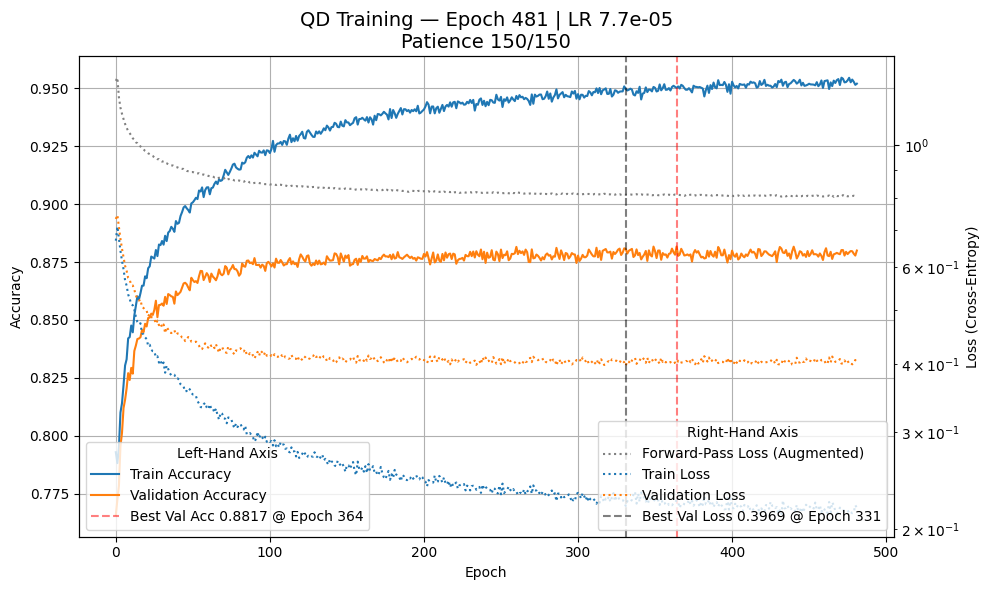

Epoch 481: train_acc=0.9520  val_acc=0.8800  val_loss=0.4016  lr=7.7e-05 patience=150/150
Early stopping at epoch 481 after 150 epochs without improvement.


,epoch,train_forward_pass_loss,train_acc,train_loss,val_acc,val_loss
0,0,1.307331,0.792865,0.669517,0.765792,0.733268
1,1,1.324520,0.788125,0.710240,0.772375,0.745600
2,2,1.220215,0.794958,0.676905,0.778333,0.709216
3,3,1.168121,0.809979,0.641822,0.795375,0.674590
4,4,1.138903,0.814010,0.615305,0.801250,0.647538
...,...,...,...,...,...,...
477,477,0.807555,0.952646,0.214988,0.879750,0.401337
478,478,0.806973,0.953812,0.213991,0.879667,0.398991
479,479,0.808125,0.952844,0.214914,0.878583,0.402057
480,480,0.806898,0.951542,0.221336,0.877792,0.406364


In [ ]:
# Train (or resume with: resume_from=QD_CHECKPOINT_DIR / "epoch_X.pt")
qd_nn_train(
    progressbar=2,
    # resume_from=QD_CHECKPOINT_DIR / "epoch_431.pt",
)


<div class='exercise-r'>

#### 2.3.3 Trace Plots

Plot your model's training accuracy and validation accuracy as a function of epochs.

</div>


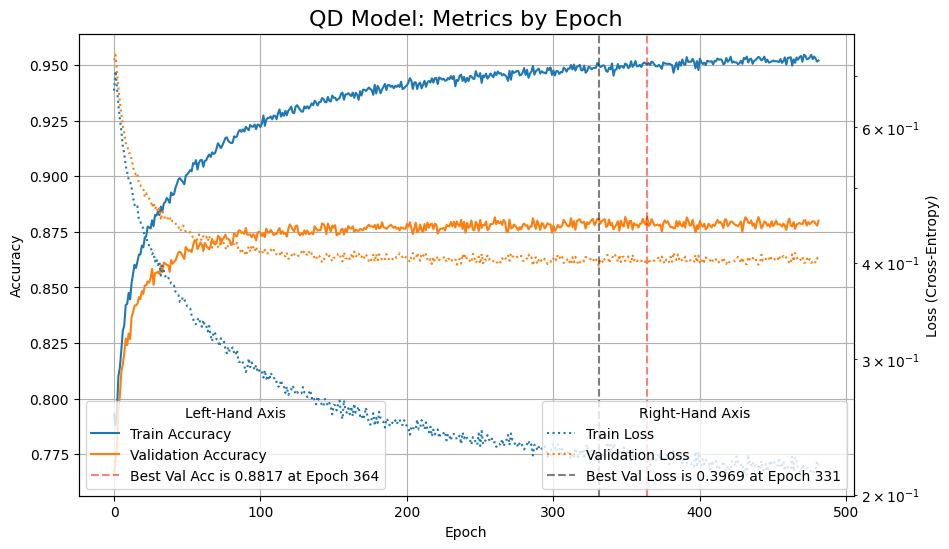

Final Train Accuracy: 0.9520
Final Validation Accuracy: 0.8800


In [13]:
# plot train and val acc as a function of epochs for the qd model
qd_results = pd.read_csv(QD_METRICS_DIR / "epoch_metrics.csv")

qd_best_val_acc_epoch = qd_results["val_acc"].idxmax()
qd_best_val_loss_epoch = qd_results["val_loss"].idxmin()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(
    qd_results["epoch"],
    qd_results["train_acc"],
    label="Train Accuracy",
)
ax1.plot(
    qd_results["epoch"],
    qd_results["val_acc"],
    label="Validation Accuracy",
)
ax1.axvline(
    x=qd_best_val_acc_epoch,
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Best Val Acc is {qd_results.loc[qd_best_val_acc_epoch, 'val_acc']:.4f} "
    + f"at Epoch {qd_best_val_acc_epoch}",
)
ax1.set_title("QD Model: Metrics by Epoch", fontsize=16)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend(loc="lower left", title="Left-Hand Axis")
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(
    qd_results["epoch"],
    qd_results["train_loss"],
    label="Train Loss",
    linestyle=":",
)
ax2.plot(
    qd_results["epoch"],
    qd_results["val_loss"],
    label="Validation Loss",
    linestyle=":",
)
ax2.axvline(
    x=qd_best_val_loss_epoch,
    color="black",
    linestyle="--",
    alpha=0.5,
    label=f"Best Val Loss is {qd_results.loc[qd_best_val_loss_epoch, 'val_loss']:.4f} "
    + f"at Epoch {qd_best_val_loss_epoch}",
)
ax2.set_ylabel("Loss (Cross-Entropy)")
ax2.set_yscale("log")
ax2.legend(loc="lower right", title="Right-Hand Axis")

plt.show()

print(f"Final Train Accuracy: {qd_results.tail(1)['train_acc'].values[0]:.4f}")
print(f"Final Validation Accuracy: {qd_results.tail(1)['val_acc'].values[0]:.4f}")


<div class='exercise-r'>

#### 2.3.4 Error analysis that remains reproducible

Accuracy alone won’t tell you what your model is _getting wrong_, or whether the mistakes are random vs. systematic. In this question you’ll diagnose failure modes by looking at cases where the model is **wrong but very confident**—often the most revealing errors.

**Important reproducibility requirement:** you will likely keep iterating on your model after this point, but your error analysis should remain valid and rerunnable later. To do that, pick a “snapshot” model (e.g., your current best at this stage) and make it reproducible: **save its weights (or otherwise freeze it)** and make sure you can **reload it** to reproduce the same validation predictions. If you later improve your model for Kaggle, you should still be able to rerun this analysis on the snapshot without it silently changing.

Using your **validation set**, identify at least **12** examples where the snapshot model’s prediction is **incorrect** but its predicted probability for the chosen class is **high** (e.g., ≥ 0.90; if needed, choose a threshold that yields ~10–20 examples and report it). Display these examples in a grid, annotating **true label**, **predicted label**, and **confidence**.

In **5–8 sentences**, describe the main patterns you observe (recurring class confusions, ambiguous drawings, rotation/scale/centering issues, missing strokes, etc.). Then propose **one concrete training change** targeted at a pattern you saw (augmentation, regularization, training procedure, etc.), and briefly justify why it should help.

</div>


<div class='exercise-r'>

#### 2.3.5 Discussion of Approach

In a few sentences, describe the various approaches you have taken to improve the performance of your regularized model as well as any additional observations you might have regarding your training and Kaggle results.

</div>


_Your answer here_


<div class='exercise-r'>

#### 2.3.6 Generating Submission CSV

Generate your test-set class predictions using your regularized model. Save those predictions to a `.csv` formatted file. Submit that `.csv` file to the CS1090B Kaggle Competition for leaderboard scoring.

**IMPORTANT:** For Kaggle to accept and score your submitted `.csv` file, it MUST contain 2 columns. The first column must be named `"id"` and needs to contain the test observation index numbers corresponding to each of your 30,000 predictions, the second column must be named `"label"` and needs to contain your class predictions (i.e. `cat` or `dog` etc.) for each corresponding test observation index location. A sample submission file has been provided to you.

</div>


In [14]:
qd_model_metrics = pd.read_csv(QD_METRICS_DIR / "epoch_metrics.csv")
qd_best_val_acc_epoch = qd_model_metrics["val_acc"].idxmax()
qd_model_metrics.sort_values("val_acc", ascending=False)


,epoch,train_forward_pass_loss,train_acc,train_loss,val_acc,val_loss
364,364,0.812111,0.950188,0.225917,0.881708,0.399270
349,349,0.810394,0.950635,0.224994,0.881667,0.402459
440,440,0.806763,0.953667,0.217845,0.881625,0.398154
260,260,0.815787,0.946750,0.234256,0.881542,0.399330
391,391,0.810526,0.953552,0.219966,0.881500,0.401071
...,...,...,...,...,...,...
4,4,1.138903,0.814010,0.615305,0.801250,0.647538
3,3,1.168121,0.809979,0.641822,0.795375,0.674590
2,2,1.220215,0.794958,0.676905,0.778333,0.709216
1,1,1.324520,0.788125,0.710240,0.772375,0.745600


In [15]:
# generate test predictions for the QD model using the best val acc epoch checkpoint
QD_SUBMISSION_DIR = Path("./models/submissions/qd")
QD_SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

gc.collect()
torch.cuda.empty_cache()

best_ckpt_path = QD_CHECKPOINT_DIR / f"epoch_{qd_best_val_acc_epoch}.pt"
checkpoint = torch.load(best_ckpt_path, weights_only=False, map_location="cpu")
model = QDNN_Factory.build().to(device)
# Strip _orig_mod. prefix added by torch.compile
state_dict = {
    k.removeprefix("_orig_mod."): v for k, v in checkpoint["model_state_dict"].items()
}
model.load_state_dict(state_dict)
model.eval()
X_test_t = torch.tensor(qd_X_test, dtype=torch.float32).to(device)
test_logits = []
batch_size = 1024
with torch.no_grad():
    for i in tqdm_notebook(
        range(0, len(X_test_t), batch_size),
        desc="Predicting Test Batches",
        leave=True,
    ):
        batch = X_test_t[i : min(i + batch_size, len(X_test_t))].to(device)
        logits = model(batch).cpu()
        test_logits.append(logits)
        del batch
test_logits = torch.cat(test_logits)
test_y_pred = torch.argmax(test_logits, dim=1).numpy()

gc.collect()
torch.cuda.empty_cache()

test_y_pred_labels = qd_label_encoder.inverse_transform(test_y_pred)
submission_df = pd.DataFrame(
    {
        "id": qd_test_df["id"],
        "label": test_y_pred_labels,
    }
)
submission_df.to_csv(QD_SUBMISSION_DIR / "quickdraw_submission.csv", index=False)
del submission_df
gc.collect()


Predicting Test Batches:   0%|          | 0/30 [00:00<?, ?it/s]

0

<div class='exercise-r'>

#### 2.3.7 Kaggle Leaderboard Name

Specify your Kaggle name that you have used as it appears on the leaderboard. We CANNOT give you credit without this.

</div>


**YOUR KAGGLE LEADERBOARD NAME:**


Andrew Jing and Hoi Cheung


<!-- BEGIN QUESTION -->

<div class='exercise-r'>
    
### 2.4 Wrap-up

</div>


- In a few sentences, please describe the aspect(s) of the assignment you found most challenging. This could be conceptual and/or related to coding and implementation.

- How many hours did you spend working on this assignment? Store this as an int or float in `hours_spent_on_hw`. If you worked on the project in a group, report the _average_ time spent per person.


In [ ]:
hours_spent_on_hw = ...


_Your answer here_


In [ ]:
time_end = time.time()
print(f"It took {(time_end - time_start) / 60:.2f} minutes for this notebook to run")


**This concludes HW1. Thank you!**
